In [1]:
import numpy as np
import pandas as pd
import scipy,sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import os

## Load in the Data
The data we are exploring is from the Mobile Crisis Services of Lane County program implemented in 2024. 

In [2]:
mcslc = pd.read_excel('data/MCSLC.xlsx')
mcslc.head()

,ID,End Point of Dispatch,City,Dispatch Request Date & Time,Dispatch Date & Time,Arrival on Scene Date & Time,Engagement with Client Date & Time,MCIT Departure Date & Time,Reason for Dispatch #1,Reason for Dispatch #2,Reason for Dispatch #3,Reason for Dispatch #4,Reason for Dispatch #5,Disposition,Minutes: Request → Dispatch,Minutes: Dispatch → Arrival,Minutes: Arrival → Engagement,Minutes: Arrival → Departure
0,12236,Cancelled,Eugene,2025-05-12 13:29:00,2025-05-12 13:34:00,2025-05-12 00:00:00,2025-05-12 00:00:00,2025-05-12 14:03:00,Harm/risk of harm to self/others/property,Disorganized behavior,Agitation or disruptive behavior,NaN,NaN,Arrest,5.0,NaN,0.0,NaN
1,12574,Cancelled,Unknown,2025-12-05 17:41:00,2025-12-05 17:47:00,2025-12-05 18:06:00,NaT,2025-12-05 18:12:00,Agitation or disruptive behavior,NaN,NaN,NaN,NaN,Arrest,6.0,19.0,NaN,NaN
2,12888,Cancelled,Eugene,2025-07-25 21:10:00,2025-07-25 21:14:00,2025-07-25 21:28:00,2025-07-25 21:30:00,2025-07-25 21:36:00,Agitation or disruptive behavior,NaN,NaN,NaN,NaN,Arrest,4.0,14.0,2.0,8.0
3,10504,Engaged Client,Eugene,2025-03-29 22:29:00,2025-03-29 22:43:00,2025-03-29 23:21:00,2025-03-29 23:28:00,2025-03-29 23:58:00,Harm/risk of harm to self/others/property,Disorganized behavior,Agitation or disruptive behavior,NaN,NaN,Arrest,14.0,38.0,7.0,37.0
4,12220,Engaged Client,Eugene,2025-04-26 18:52:00,2025-04-26 18:54:00,2025-04-26 19:05:00,2025-04-26 19:07:00,2025-04-26 19:32:00,Disorganized behavior,Agitation or disruptive behavior,NaN,NaN,NaN,Arrest,2.0,11.0,2.0,27.0


## Data Preparation
The variables in this data frame are defined as:

Variable       | Description
-------------- | ------------------------------------------------------------------
ID | Record of the call
End Point of Dispatch | What occured with the call according to dispatch
City | Location of where the call was placed
Dispatch Request Date & Time | Timestamp of when Dispatch made a request for intervention
Dispatch Date & Time | Timestamp of when the mobile response team is dispatched
Arrival on Scene Date & Time | Timestamp of when the mobile response team arrives on the scene
Engagement with Client Date & Time | Timestamp of when the mobile response team begins to engage with the client
MCIT Departure Date & Time | Timestamp of MCIT departure after engaging with client
Reasons for Dispatch #1-#5 | A collection of different categories for dispatch
Disposition | The outcome of the call 
Minutes: Request → Dispatch | The time difference in minutes between Dispatch Request and Dispatch of MCIT
Minutes: Dispatch → Arrival | The time difference in minutes between Dispatch of MCIT and their Arrival to the scene
Minutes: Arrival → Engagement | The time difference in minutes between MCIT Arrival and their Engagement with the client
Minutes: Arrival → Departure | The time difference in minutes between MCIT Arrival and their Departure from the scene

In [3]:
type(mcslc.loc[0, "Dispatch Request Date & Time"])

pandas._libs.tslibs.timestamps.Timestamp

In [4]:
mcslc["End Point of Dispatch"].unique()

array(['Cancelled', 'Engaged Client', 'Engaged client',
       'No contact due to safety concern', 'Refused', nan,
       'Client declined to engage', 'Unable to locate client',
       'Client declined  to engage', 'Dispatch canceled before arrival',
       'Other', 'Unable to Locate'], dtype=object)

In [5]:
mcslc["Disposition"].unique()

array(['Arrest', 'Crisis walk-in Center', 'Emergency Department', 'Other',
       'Remained in community', 'Respite', 'Sobering or Detox Facility',
       'Sobering/Detox Facility'], dtype=object)

In [6]:
mcslc["Reason for Dispatch #1"].unique()

array(['Harm/risk of harm to self/others/property',
       'Agitation or disruptive behavior', 'Disorganized behavior', nan,
       'Difficulty functioning', 'Needing social/mental health services',
       'Substance use', 'Adult Social/interpersonal problems',
       'Suicidality or suicide attempt', 'Trauma', 'Running away',
       'Other', 'Paranoia', 'Concerns about treatment engagement'],
      dtype=object)

In [7]:
mcslc_clean=mcslc.copy()
mcslc_clean["End Point of Dispatch"] = mcslc_clean["End Point of Dispatch"].str.title()

In [8]:
mcslc_clean["End Point of Dispatch"] = mcslc_clean["End Point of Dispatch"].replace("Client Declined  To Engage", "Client Declined To Engage")
mcslc_clean["End Point of Dispatch"].unique()

array(['Cancelled', 'Engaged Client', 'No Contact Due To Safety Concern',
       'Refused', nan, 'Client Declined To Engage',
       'Unable To Locate Client', 'Dispatch Canceled Before Arrival',
       'Other', 'Unable To Locate'], dtype=object)

In [9]:
mcslc_clean["Disposition"] = mcslc_clean["Disposition"].replace("Sobering/Detox Facility", "Sobering or Detox Facility")
mcslc_clean["Disposition"].unique()

array(['Arrest', 'Crisis walk-in Center', 'Emergency Department', 'Other',
       'Remained in community', 'Respite', 'Sobering or Detox Facility'],
      dtype=object)

In [10]:
mcslc_clean = mcslc_clean.dropna(subset=['Dispatch Request Date & Time', 'Dispatch Date & Time','Arrival on Scene Date & Time', 
                                   'Engagement with Client Date & Time', 'MCIT Departure Date & Time', 'Reason for Dispatch #1'])
mcslc_clean.head()

,ID,End Point of Dispatch,City,Dispatch Request Date & Time,Dispatch Date & Time,Arrival on Scene Date & Time,Engagement with Client Date & Time,MCIT Departure Date & Time,Reason for Dispatch #1,Reason for Dispatch #2,Reason for Dispatch #3,Reason for Dispatch #4,Reason for Dispatch #5,Disposition,Minutes: Request → Dispatch,Minutes: Dispatch → Arrival,Minutes: Arrival → Engagement,Minutes: Arrival → Departure
0,12236,Cancelled,Eugene,2025-05-12 13:29:00,2025-05-12 13:34:00,2025-05-12 00:00:00,2025-05-12 00:00:00,2025-05-12 14:03:00,Harm/risk of harm to self/others/property,Disorganized behavior,Agitation or disruptive behavior,NaN,NaN,Arrest,5.0,NaN,0.0,NaN
2,12888,Cancelled,Eugene,2025-07-25 21:10:00,2025-07-25 21:14:00,2025-07-25 21:28:00,2025-07-25 21:30:00,2025-07-25 21:36:00,Agitation or disruptive behavior,NaN,NaN,NaN,NaN,Arrest,4.0,14.0,2.0,8.0
3,10504,Engaged Client,Eugene,2025-03-29 22:29:00,2025-03-29 22:43:00,2025-03-29 23:21:00,2025-03-29 23:28:00,2025-03-29 23:58:00,Harm/risk of harm to self/others/property,Disorganized behavior,Agitation or disruptive behavior,NaN,NaN,Arrest,14.0,38.0,7.0,37.0
4,12220,Engaged Client,Eugene,2025-04-26 18:52:00,2025-04-26 18:54:00,2025-04-26 19:05:00,2025-04-26 19:07:00,2025-04-26 19:32:00,Disorganized behavior,Agitation or disruptive behavior,NaN,NaN,NaN,Arrest,2.0,11.0,2.0,27.0
5,12224,Engaged Client,Eugene,2025-05-12 20:48:00,2025-05-12 20:51:00,2025-05-12 21:14:00,2025-05-12 21:14:00,2025-05-12 21:57:00,Disorganized behavior,Difficulty functioning,Adult Social/interpersonal problems,Agitation or disruptive behavior,NaN,Arrest,3.0,23.0,0.0,43.0


In [11]:
mcslc_clean["Min: Request to Dispatch"] = (mcslc_clean["Dispatch Date & Time"]-mcslc_clean["Dispatch Request Date & Time"]).dt.total_seconds()/60
mcslc_clean["Min: Dispatch to Arrival"] = (mcslc_clean["Arrival on Scene Date & Time"]-mcslc_clean["Dispatch Date & Time"]).dt.total_seconds()/60
mcslc_clean["Min: Arrival to Engagement"] = (mcslc_clean["Engagement with Client Date & Time"]-mcslc_clean["Arrival on Scene Date & Time"]).dt.total_seconds()/60
mcslc_clean["Min: Arrival to Departure"] = (mcslc_clean["MCIT Departure Date & Time"]-mcslc_clean["Arrival on Scene Date & Time"]).dt.total_seconds()/60
mcslc_clean["Min: Total Response Time"] = (mcslc_clean["MCIT Departure Date & Time"]-mcslc_clean["Dispatch Request Date & Time"]).dt.total_seconds()/60
mcslc_clean.head()

,ID,End Point of Dispatch,City,Dispatch Request Date & Time,Dispatch Date & Time,Arrival on Scene Date & Time,Engagement with Client Date & Time,MCIT Departure Date & Time,Reason for Dispatch #1,Reason for Dispatch #2,...,Disposition,Minutes: Request → Dispatch,Minutes: Dispatch → Arrival,Minutes: Arrival → Engagement,Minutes: Arrival → Departure,Min: Request to Dispatch,Min: Dispatch to Arrival,Min: Arrival to Engagement,Min: Arrival to Departure,Min: Total Response Time
0,12236,Cancelled,Eugene,2025-05-12 13:29:00,2025-05-12 13:34:00,2025-05-12 00:00:00,2025-05-12 00:00:00,2025-05-12 14:03:00,Harm/risk of harm to self/others/property,Disorganized behavior,...,Arrest,5.0,NaN,0.0,NaN,5.0,-814.0,0.0,843.0,34.0
2,12888,Cancelled,Eugene,2025-07-25 21:10:00,2025-07-25 21:14:00,2025-07-25 21:28:00,2025-07-25 21:30:00,2025-07-25 21:36:00,Agitation or disruptive behavior,NaN,...,Arrest,4.0,14.0,2.0,8.0,4.0,14.0,2.0,8.0,26.0
3,10504,Engaged Client,Eugene,2025-03-29 22:29:00,2025-03-29 22:43:00,2025-03-29 23:21:00,2025-03-29 23:28:00,2025-03-29 23:58:00,Harm/risk of harm to self/others/property,Disorganized behavior,...,Arrest,14.0,38.0,7.0,37.0,14.0,38.0,7.0,37.0,89.0
4,12220,Engaged Client,Eugene,2025-04-26 18:52:00,2025-04-26 18:54:00,2025-04-26 19:05:00,2025-04-26 19:07:00,2025-04-26 19:32:00,Disorganized behavior,Agitation or disruptive behavior,...,Arrest,2.0,11.0,2.0,27.0,2.0,11.0,2.0,27.0,40.0
5,12224,Engaged Client,Eugene,2025-05-12 20:48:00,2025-05-12 20:51:00,2025-05-12 21:14:00,2025-05-12 21:14:00,2025-05-12 21:57:00,Disorganized behavior,Difficulty functioning,...,Arrest,3.0,23.0,0.0,43.0,3.0,23.0,0.0,43.0,69.0


In [12]:
cols = ["Min: Request to Dispatch", "Min: Dispatch to Arrival", "Min: Arrival to Engagement", "Min: Arrival to Departure"]
mcslc_clean = mcslc_clean[(mcslc_clean[cols]>=0).all(axis=1)]
mcslc_clean.head()

,ID,End Point of Dispatch,City,Dispatch Request Date & Time,Dispatch Date & Time,Arrival on Scene Date & Time,Engagement with Client Date & Time,MCIT Departure Date & Time,Reason for Dispatch #1,Reason for Dispatch #2,...,Disposition,Minutes: Request → Dispatch,Minutes: Dispatch → Arrival,Minutes: Arrival → Engagement,Minutes: Arrival → Departure,Min: Request to Dispatch,Min: Dispatch to Arrival,Min: Arrival to Engagement,Min: Arrival to Departure,Min: Total Response Time
2,12888,Cancelled,Eugene,2025-07-25 21:10:00,2025-07-25 21:14:00,2025-07-25 21:28:00,2025-07-25 21:30:00,2025-07-25 21:36:00,Agitation or disruptive behavior,NaN,...,Arrest,4.0,14.0,2.0,8.0,4.0,14.0,2.0,8.0,26.0
3,10504,Engaged Client,Eugene,2025-03-29 22:29:00,2025-03-29 22:43:00,2025-03-29 23:21:00,2025-03-29 23:28:00,2025-03-29 23:58:00,Harm/risk of harm to self/others/property,Disorganized behavior,...,Arrest,14.0,38.0,7.0,37.0,14.0,38.0,7.0,37.0,89.0
4,12220,Engaged Client,Eugene,2025-04-26 18:52:00,2025-04-26 18:54:00,2025-04-26 19:05:00,2025-04-26 19:07:00,2025-04-26 19:32:00,Disorganized behavior,Agitation or disruptive behavior,...,Arrest,2.0,11.0,2.0,27.0,2.0,11.0,2.0,27.0,40.0
5,12224,Engaged Client,Eugene,2025-05-12 20:48:00,2025-05-12 20:51:00,2025-05-12 21:14:00,2025-05-12 21:14:00,2025-05-12 21:57:00,Disorganized behavior,Difficulty functioning,...,Arrest,3.0,23.0,0.0,43.0,3.0,23.0,0.0,43.0,69.0
7,12311,Engaged Client,Eugene,2024-08-22 19:00:54,2024-08-22 19:02:00,2024-08-22 19:07:00,2024-08-22 19:07:00,2024-08-22 19:23:00,Difficulty functioning,Disorganized behavior,...,Arrest,2.0,5.0,0.0,16.0,1.1,5.0,0.0,16.0,22.1


In [14]:
mcslc_clean["Year_Month"] = mcslc_clean["Dispatch Request Date & Time"].dt.to_period("M").dt.to_timestamp()
mcslc_clean["Year"] = mcslc_clean["Dispatch Request Date & Time"].dt.year
mcslc_clean.head()

,ID,End Point of Dispatch,City,Dispatch Request Date & Time,Dispatch Date & Time,Arrival on Scene Date & Time,Engagement with Client Date & Time,MCIT Departure Date & Time,Reason for Dispatch #1,Reason for Dispatch #2,...,Minutes: Dispatch → Arrival,Minutes: Arrival → Engagement,Minutes: Arrival → Departure,Min: Request to Dispatch,Min: Dispatch to Arrival,Min: Arrival to Engagement,Min: Arrival to Departure,Min: Total Response Time,Year_Month,Year
2,12888,Cancelled,Eugene,2025-07-25 21:10:00,2025-07-25 21:14:00,2025-07-25 21:28:00,2025-07-25 21:30:00,2025-07-25 21:36:00,Agitation or disruptive behavior,NaN,...,14.0,2.0,8.0,4.0,14.0,2.0,8.0,26.0,2025-07-01,2025
3,10504,Engaged Client,Eugene,2025-03-29 22:29:00,2025-03-29 22:43:00,2025-03-29 23:21:00,2025-03-29 23:28:00,2025-03-29 23:58:00,Harm/risk of harm to self/others/property,Disorganized behavior,...,38.0,7.0,37.0,14.0,38.0,7.0,37.0,89.0,2025-03-01,2025
4,12220,Engaged Client,Eugene,2025-04-26 18:52:00,2025-04-26 18:54:00,2025-04-26 19:05:00,2025-04-26 19:07:00,2025-04-26 19:32:00,Disorganized behavior,Agitation or disruptive behavior,...,11.0,2.0,27.0,2.0,11.0,2.0,27.0,40.0,2025-04-01,2025
5,12224,Engaged Client,Eugene,2025-05-12 20:48:00,2025-05-12 20:51:00,2025-05-12 21:14:00,2025-05-12 21:14:00,2025-05-12 21:57:00,Disorganized behavior,Difficulty functioning,...,23.0,0.0,43.0,3.0,23.0,0.0,43.0,69.0,2025-05-01,2025
7,12311,Engaged Client,Eugene,2024-08-22 19:00:54,2024-08-22 19:02:00,2024-08-22 19:07:00,2024-08-22 19:07:00,2024-08-22 19:23:00,Difficulty functioning,Disorganized behavior,...,5.0,0.0,16.0,1.1,5.0,0.0,16.0,22.1,2024-08-01,2024


In [15]:
mcslc_eug = mcslc_clean.loc[mcslc_clean["City"]== 'Eugene']
mcslc_eug.head()

,ID,End Point of Dispatch,City,Dispatch Request Date & Time,Dispatch Date & Time,Arrival on Scene Date & Time,Engagement with Client Date & Time,MCIT Departure Date & Time,Reason for Dispatch #1,Reason for Dispatch #2,...,Minutes: Dispatch → Arrival,Minutes: Arrival → Engagement,Minutes: Arrival → Departure,Min: Request to Dispatch,Min: Dispatch to Arrival,Min: Arrival to Engagement,Min: Arrival to Departure,Min: Total Response Time,Year_Month,Year
2,12888,Cancelled,Eugene,2025-07-25 21:10:00,2025-07-25 21:14:00,2025-07-25 21:28:00,2025-07-25 21:30:00,2025-07-25 21:36:00,Agitation or disruptive behavior,NaN,...,14.0,2.0,8.0,4.0,14.0,2.0,8.0,26.0,2025-07-01,2025
3,10504,Engaged Client,Eugene,2025-03-29 22:29:00,2025-03-29 22:43:00,2025-03-29 23:21:00,2025-03-29 23:28:00,2025-03-29 23:58:00,Harm/risk of harm to self/others/property,Disorganized behavior,...,38.0,7.0,37.0,14.0,38.0,7.0,37.0,89.0,2025-03-01,2025
4,12220,Engaged Client,Eugene,2025-04-26 18:52:00,2025-04-26 18:54:00,2025-04-26 19:05:00,2025-04-26 19:07:00,2025-04-26 19:32:00,Disorganized behavior,Agitation or disruptive behavior,...,11.0,2.0,27.0,2.0,11.0,2.0,27.0,40.0,2025-04-01,2025
5,12224,Engaged Client,Eugene,2025-05-12 20:48:00,2025-05-12 20:51:00,2025-05-12 21:14:00,2025-05-12 21:14:00,2025-05-12 21:57:00,Disorganized behavior,Difficulty functioning,...,23.0,0.0,43.0,3.0,23.0,0.0,43.0,69.0,2025-05-01,2025
7,12311,Engaged Client,Eugene,2024-08-22 19:00:54,2024-08-22 19:02:00,2024-08-22 19:07:00,2024-08-22 19:07:00,2024-08-22 19:23:00,Difficulty functioning,Disorganized behavior,...,5.0,0.0,16.0,1.1,5.0,0.0,16.0,22.1,2024-08-01,2024


In [16]:
minutes = ["Min: Request to Dispatch", "Min: Dispatch to Arrival","Min: Arrival to Engagement", "Min: Arrival to Departure", "Min: Total Response Time"]
monthly_average_times_eug = (mcslc_eug.groupby(["Year_Month"])[minutes].mean().reset_index())
monthly_average_times_eug

,Year_Month,Min: Request to Dispatch,Min: Dispatch to Arrival,Min: Arrival to Engagement,Min: Arrival to Departure,Min: Total Response Time
0,2024-08-01,13.481818,15.613636,2.022727,32.909091,62.004545
1,2024-09-01,24.205691,19.048780,4.987805,35.243902,78.498374
2,2024-10-01,10.333333,19.083333,4.416667,34.333333,63.750000
3,2025-01-01,13.161765,14.250000,2.235294,35.235294,62.647059
4,2025-02-01,15.361446,14.987952,2.409639,32.542169,62.891566
5,2025-03-01,15.850467,14.289720,2.252336,35.485981,65.626168
6,2025-04-01,14.369942,13.774566,2.138728,31.855491,60.000000
7,2025-05-01,22.650350,14.405594,2.881119,28.867133,65.923077
8,2025-06-01,25.329032,13.790376,6.600108,32.322742,71.442151
9,2025-07-01,26.204240,16.144737,2.074561,29.498684,71.847661


In [17]:
minutes = ["Min: Request to Dispatch", "Min: Dispatch to Arrival","Min: Arrival to Engagement", "Min: Arrival to Departure", "Min: Total Response Time"]
monthly_average_time_eug_tab = monthly_average_times_eug.melt(id_vars="Year_Month", value_vars=minutes, var_name="Time Metric", value_name="Minutes")
monthly_average_time_eug_tab

,Year_Month,Time Metric,Minutes
0,2024-08-01,Min: Request to Dispatch,13.481818
1,2024-09-01,Min: Request to Dispatch,24.205691
2,2024-10-01,Min: Request to Dispatch,10.333333
3,2025-01-01,Min: Request to Dispatch,13.161765
4,2025-02-01,Min: Request to Dispatch,15.361446
...,...,...,...
70,2025-08-01,Min: Total Response Time,235.633629
71,2025-09-01,Min: Total Response Time,485.091954
72,2025-10-01,Min: Total Response Time,79.074510
73,2025-11-01,Min: Total Response Time,67.084419


<Axes: xlabel='Year_Month', ylabel='Minutes'>

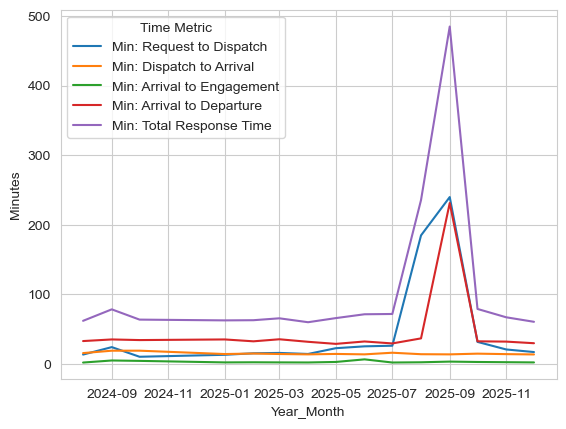

In [18]:
sns.set_style("whitegrid")
sns.lineplot(data=monthly_average_time_eug_tab, x="Year_Month", y="Minutes", hue="Time Metric")

In [19]:
minutes = ["Min: Request to Dispatch", "Min: Dispatch to Arrival","Min: Arrival to Engagement", "Min: Arrival to Departure", "Min: Total Response Time"]
dispatch_average_times_eug = (mcslc_eug.groupby(["Year", "Reason for Dispatch #1"])[minutes].mean().reset_index())
dispatch_average_times_eug 

,Year,Reason for Dispatch #1,Min: Request to Dispatch,Min: Dispatch to Arrival,Min: Arrival to Engagement,Min: Arrival to Departure,Min: Total Response Time
0,2024,Adult Social/interpersonal problems,19.090909,15.909091,6.909091,44.272727,79.272727
1,2024,Agitation or disruptive behavior,22.001351,17.000000,3.675676,36.540541,75.541892
2,2024,Difficulty functioning,35.357143,24.357143,1.714286,31.714286,91.428571
3,2024,Disorganized behavior,20.786364,23.000000,2.090909,33.636364,77.422727
4,2024,Harm/risk of harm to self/others/property,16.245402,15.620690,5.448276,33.137931,65.004023
5,2024,Needing social/mental health services,2.333333,19.333333,3.000000,46.000000,67.666667
6,2024,Other,10.372222,14.222222,2.444444,29.111111,53.705556
7,2024,Paranoia,6.000000,14.000000,2.000000,32.000000,52.000000
8,2024,Running away,34.500000,11.000000,34.500000,47.000000,92.500000
9,2024,Substance use,19.000000,18.000000,1.750000,34.250000,71.250000


In [20]:
minutes = ["Min: Request to Dispatch", "Min: Dispatch to Arrival","Min: Arrival to Engagement", "Min: Arrival to Departure", "Min: Total Response Time"]
dispatch_melt = dispatch_average_times_eug.melt(id_vars = ["Year", "Reason for Dispatch #1"], value_vars= minutes, var_name="Metric", value_name= "Minutes")

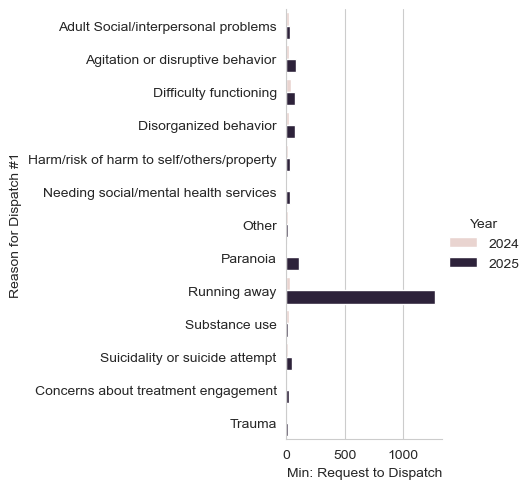

In [21]:
sns.catplot(data=dispatch_average_times_eug, x = "Min: Request to Dispatch", y = "Reason for Dispatch #1", hue = "Year", kind = "bar")

In [22]:
mcslc_spg = mcslc_clean.loc[mcslc_clean["City"]== 'Springfield']
mcslc_spg.head()

,ID,End Point of Dispatch,City,Dispatch Request Date & Time,Dispatch Date & Time,Arrival on Scene Date & Time,Engagement with Client Date & Time,MCIT Departure Date & Time,Reason for Dispatch #1,Reason for Dispatch #2,...,Minutes: Dispatch → Arrival,Minutes: Arrival → Engagement,Minutes: Arrival → Departure,Min: Request to Dispatch,Min: Dispatch to Arrival,Min: Arrival to Engagement,Min: Arrival to Departure,Min: Total Response Time,Year_Month,Year
39,12245,Client Declined To Engage,Springfield,2024-08-22 00:00:00,2024-08-22 00:00:00,2024-08-22 00:00:00,2024-08-22 00:00:00,2024-08-22 00:00:00,Agitation or disruptive behavior,Difficulty functioning,...,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,2024-08-01,2024
48,10052,Engaged Client,Springfield,2025-01-14 14:51:00,2025-01-14 15:04:00,2025-01-14 15:31:00,2025-01-14 15:33:00,2025-01-14 16:32:00,Needing social/mental health services,Harm/risk of harm to self/others/property,...,27.0,2.0,61.0,13.0,27.0,2.0,61.0,101.0,2025-01-01,2025
49,10062,Engaged Client,Springfield,2025-01-16 14:56:00,2025-01-16 15:19:00,2025-01-16 15:43:00,2025-01-16 15:44:00,2025-01-16 16:28:00,Running away,Harm/risk of harm to self/others/property,...,24.0,1.0,45.0,23.0,24.0,1.0,45.0,92.0,2025-01-01,2025
51,10070,Engaged Client,Springfield,2025-02-01 16:29:00,2025-02-01 16:31:00,2025-02-01 16:50:00,2025-02-01 16:50:00,2025-02-01 17:13:00,Suicidality or suicide attempt,Harm/risk of harm to self/others/property,...,19.0,0.0,23.0,2.0,19.0,0.0,23.0,44.0,2025-02-01,2025
74,10180,Engaged Client,Springfield,2025-01-31 15:38:00,2025-01-31 15:59:00,2025-01-31 16:05:00,2025-01-31 16:09:00,2025-01-31 16:50:00,Trauma,Needing social/mental health services,...,6.0,4.0,45.0,21.0,6.0,4.0,45.0,72.0,2025-01-01,2025


In [23]:
mcslc_oth = mcslc_clean.loc[mcslc_clean["City"]== 'Other']
mcslc_oth.head()

,ID,End Point of Dispatch,City,Dispatch Request Date & Time,Dispatch Date & Time,Arrival on Scene Date & Time,Engagement with Client Date & Time,MCIT Departure Date & Time,Reason for Dispatch #1,Reason for Dispatch #2,...,Minutes: Dispatch → Arrival,Minutes: Arrival → Engagement,Minutes: Arrival → Departure,Min: Request to Dispatch,Min: Dispatch to Arrival,Min: Arrival to Engagement,Min: Arrival to Departure,Min: Total Response Time,Year_Month,Year
14,14627,NaN,Other,2025-09-07 21:12:00,2025-09-07 21:17:00,2025-09-07 22:07:00,2025-09-07 22:08:00,2025-09-08 00:00:00,Agitation or disruptive behavior,Disorganized behavior,...,50.0,1.0,113.0,5.0,50.0,1.0,113.0,168.0,2025-09-01,2025
15,14671,NaN,Other,2025-09-16 02:23:00,2025-09-16 02:39:00,2025-09-16 03:02:00,2025-09-16 03:03:00,2025-09-16 03:32:00,Disorganized behavior,Harm/risk of harm to self/others/property,...,23.0,1.0,30.0,16.0,23.0,1.0,30.0,69.0,2025-09-01,2025
43,12506,Client Declined To Engage,Other,2024-10-05 14:28:00,2024-10-05 14:30:00,2024-10-05 15:20:00,2024-10-05 15:22:00,2024-10-05 15:33:00,Agitation or disruptive behavior,Adult Social/interpersonal problems,...,50.0,2.0,13.0,2.0,50.0,2.0,13.0,65.0,2024-10-01,2024
47,10046,Engaged Client,Other,2025-02-02 18:57:00,2025-02-02 19:09:00,2025-02-02 19:36:00,2025-02-02 19:38:00,2025-02-02 20:30:00,Disorganized behavior,Difficulty functioning,...,27.0,2.0,54.0,12.0,27.0,2.0,54.0,93.0,2025-02-01,2025
53,10084,Engaged Client,Other,2025-01-18 19:59:00,2025-01-18 20:46:00,2025-01-18 21:03:00,2025-01-18 21:09:00,2025-01-18 21:57:00,Needing social/mental health services,Paranoia,...,17.0,6.0,54.0,47.0,17.0,6.0,54.0,118.0,2025-01-01,2025
